# Evaluación 1

**Integrante 1:** Cristina Morán

**Integrante 2:** Alonso Valderrama

**Integrante 3:** Amasis Guzmán

**Correo Electrónico integrante 1:** cristina.moran2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** alonso.valderrama2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 3:** amasis.guzman2201@alumnos.ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

#Carga de datos

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

--2026-04-17 03:41:22--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771759 (2.6M) [text/plain]
Saving to: ‘dataset_churn_dirty.csv.13’

dataset_churn_dirty 100%[===================>]   2.64M  --.-KB/s    in 0.1s    

2026-04-17 03:41:23 (23.1 MB/s) - ‘dataset_churn_dirty.csv.13’ saved [2771759/2771759]



In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

In [3]:
#Carga el set de datos
data = pd.read_csv('dataset_churn_dirty.csv')

#Para mostrar en una tabla los datos del archivo
data.head() 

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
0,1,39.0,NaN,76,42,30.297419,0,70965.479058,47431.757551,Other,Enterprise,West,NaN,Yes,Desktop,1
1,2,69.0,1.352838e+06,46,27,50.666766,3,62653.316701,26134.009301,Other,Basic,South,Debit Card,No,Mobile,1
2,3,NaN,9.127957e+05,83,23,53.086839,1,46918.415548,15390.195033,NaN,Enterprise,West,NaN,No,Mobile,0
3,4,79.0,7.955275e+05,45,23,55.197774,1,22665.546094,41163.281718,Female,Premium,South,Debit Card,No,Tablet,1
4,5,52.0,4.425135e+05,98,29,67.781999,3,58510.036769,14704.401069,Male,Basic,West,Credit Card,Yes,Mobile,0


In [4]:
# Cantidad de observaciones y columnas
data.shape

(21000, 16)

Comentario: Esto quiere decir que los datos del archivo \.csv ingresado poseen 16 columnas y cada una de ellas 21000 valores\.

# Revisión de nulos

In [5]:
# revisión de valores faltantes y tipos de datos
data.info()

# muestra la cantidad de nulos por columna
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            21000 non-null  int64  
 1   age                    19964 non-null  float64
 2   monthly_income         19962 non-null  float64
 3   tenure_months          21000 non-null  int64  
 4   num_logins_last_month  21000 non-null  int64  
 5   avg_session_time       21000 non-null  float64
 6   support_tickets        21000 non-null  int64  
 7   account_balance        21000 non-null  float64
 8   last_payment_amount    21000 non-null  float64
 9   gender                 19947 non-null  object 
 10  subscription_type      21000 non-null  object 
 11  region                 21000 non-null  object 
 12  payment_method         19953 non-null  object 
 13  is_active              21000 non-null  object 
 14  preferred_device       21000 non-null  object 
 15  ch

customer_id                 0
age                      1036
monthly_income           1038
tenure_months               0
num_logins_last_month       0
avg_session_time            0
support_tickets             0
account_balance             0
last_payment_amount         0
gender                   1053
subscription_type           0
region                      0
payment_method           1047
is_active                   0
preferred_device            0
churn                       0
dtype: int64

De estos datos podemos observar la siguente cantidad de datos nulos:

age : 1036 datos nulos\.

monthly\_income: 1038 datos nulos\.

gender: 1053 datos nulos\.

payment\_method : 1047 datos nulos\.

Comentario respecto a nulos: Se puede apreciar que las 4 columnas con nulos son "age", "monthly\_income", "gender" y "payment\_method", además que la cantidad de datos total de cada columna debiera ser de 21000 entradas\.

In [6]:
columnas_con_nulos = data.isna().sum()[data.isna().sum() > 0]
porcentaje_nulos = (columnas_con_nulos / data.shape[0]) * 100

resultado = pd.DataFrame({
    "Cantidad Nulos": columnas_con_nulos,
    "Porcentaje Nulos (%)": porcentaje_nulos
}).round(2)

resultado

,Cantidad Nulos,Porcentaje Nulos (%)
age,1036,4.93
monthly_income,1038,4.94
gender,1053,5.01
payment_method,1047,4.99


Observamos que entre estas 4 columnas tan solo el 5% de los datos o menos son nulos\.

# Revisión de atípicos

In [7]:
# Funciones para revisión de atípicos
def buscar_atipicos(data : pd.DataFrame, columna : str) -> pd.DataFrame:
  """
  Busca valores atípicos en una columna.
  """
  # Calcular los límites
  Q1 = data[columna].quantile(0.25)
  Q3 = data[columna].quantile(0.75)
  # Calcula rango intercuartilico
  IQR = Q3 - Q1
  limite_inferior = Q1 - 1.5 * IQR 
  limite_superior = Q3 + 1.5 * IQR

  # Filtrar outliers
  return data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

def obtener_cantidad_atipicos(data : pd.DataFrame, columnas : np.array) -> dict:
  """
  Obtiene la cantidad de atípicos por cada columna.
  """
  total_atipicos = {}
  for columna in data[columnas]:
    atipicos = buscar_atipicos(data, columna)
    total_atipicos[columna] = atipicos.shape[0]
  return total_atipicos


In [8]:
atipicos_por_columna = obtener_cantidad_atipicos(data, data.describe().columns)
atipicos_por_columna

{'customer_id': 0,
 'age': 213,
 'monthly_income': 534,
 'tenure_months': 0,
 'num_logins_last_month': 58,
 'avg_session_time': 332,
 'support_tickets': 89,
 'account_balance': 136,
 'last_payment_amount': 134,
 'churn': 0}

De esto podemos decir que las columnas "monthly\_income", "num\_logins\_last\_month" y "avg\_session\_time" presentan una alta cantidad de valores atípicos\.

# Existencia de valores atípicos \(outliers\)

Analizando los datos podemos identificar la presencia de valores atípicos en múltiples variables, siendo las más relevantes: age, monthly\_income, num\_logins\_last\_month, avg\_session\_time, support\_tickets, account\_balance y last\_payment\_amount\.
 

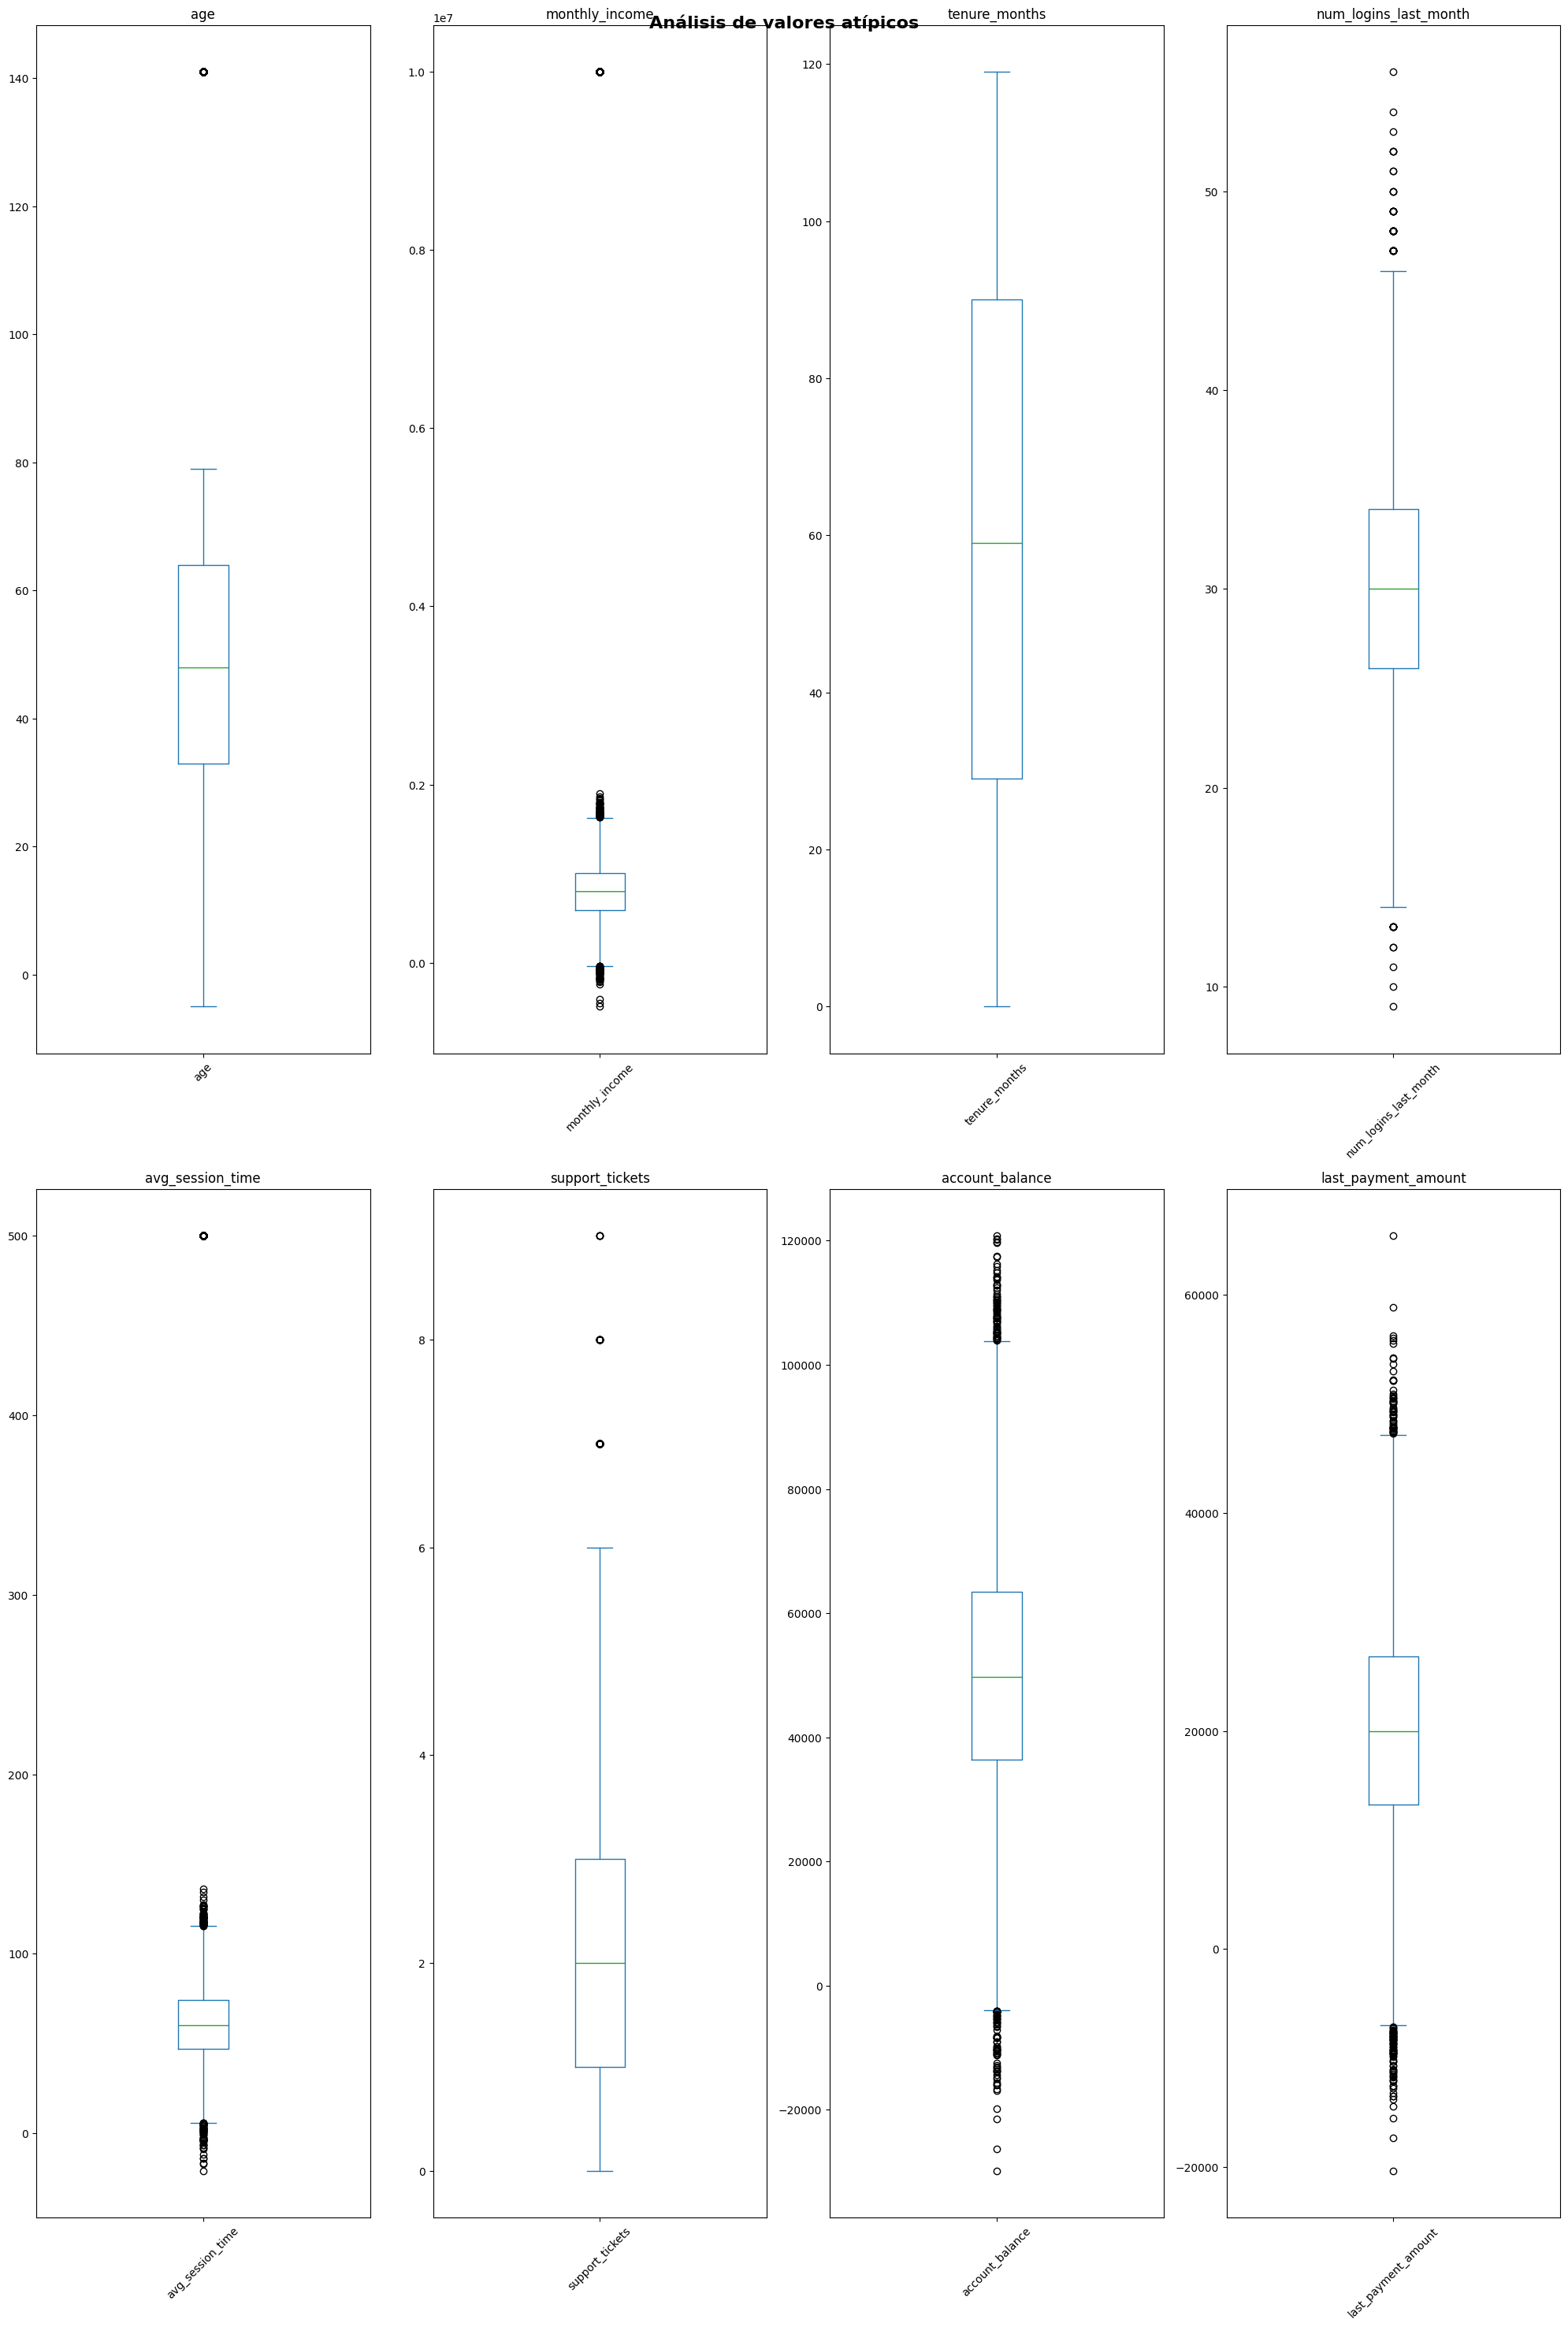

In [9]:
# Columnas numéricas para revisar atípicos
revision_atipicos = [
    'age',
    'monthly_income',
    'tenure_months',
    'num_logins_last_month',
    'avg_session_time',
    'support_tickets',
    'account_balance',
    'last_payment_amount'
]

# Crear subplots (2 filas x 4 columnas porque son 8 variables)
fig, axes = plt.subplots(2, 4, figsize=(20,30))
axes = axes.flatten()

# Graficar boxplots
for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", labelrotation=45)

# Título general
plt.suptitle("Análisis de valores atípicos", fontsize=16, fontweight="bold")

# Ajuste de diseño
plt.tight_layout()

plt.show()

age \(edad\)
\- Mayoría de las edades entre los 30 y 60 años
\- Mediana está cerca de los 40\-50
\- Existe un error o dato poco realista, valor atípico muy alto \(~140 años\)
\- Existen valores bajos, cercanos a 0
Conclusión: Hay outliers evidentes, especialmente un extremo

monthly\_income \(ingreso mensual\)
\- La mayoría de los ingresos están concentrados en un rango bajo\-medio
\- Existen valores atípicos, incluyendo uno muy alto \(~10 millones\)
\- Existen valores negativos o muy bajos
Conclusión: es una variable con alta dispersión y outliers extremos, probablemente necesita limpieza o transformación\.

EXPLICACIÓN DE CADA VARIABLE:

tenure\_months \(antigüedad en meses\)
\- Los valores están entre 0 y ~120 meses
\- La mediana está cerca de los 60 meses
\- No se observan muchos outliers
Conclusión: Distribución mayoritariamente normal y estable

num\_logins\_last\_month \(número de inicios de sesión\)
\- La mayoría de los usuarios tienen entre 25 y 35 logins
\- Existen outliers tanto Altos \(~50\-55 logins\) y Bajos \(~10\-15 logins\)
Conclusión: Existe variabilidad en el comportamiento de usuarios

avg\_session\_time \(tiempo promedio de sesión\)
\- La mayoría está entre 50 y 80
\- Existen Valores negativos \(posible error\) y un outlier extremo \(~500\)
Conclusión: Existencia de datos inconsistentes \(probablemente errores o registros mal capturados\)

account\_balance \(saldo de cuenta\)
\- La mayoría está entre 30,000 y 60,000\.
Existen valores negativos \(cuentas en deuda\)y valores muy altos \(~100,000\+\)
Conclusión: Presencia clara de outliers en ambos extremos\.

support\_tickets \(tickets de soporte\)
\- La mayoría de los usuarios tiene entre 1 y 3 tickets
\- Algunos valores llegan hasta 7–9 \(outliers\)
Conclusión: Distribución razonable, pero con algunos clientes que requieren mucho soporte

last\_payment\_amount \(último pago\)
\- La mayoría de pagos está entre 10,000 y 25,000\.
\- Hay outliers negativos \(posible error o devolución\) y unos muy altos \(~60,000\+\)
Conclusión: variable con bastante dispersión\.

En resumen , las variables con más outliers son monthly\_income, account\_balance, last\_payment\_amount, avg\_session\_time
Las variables más estables son tenure\_months, support\_tickets
Existen posibles errores de datos \(valores negativos o muy altos\)\.

In [10]:
data.drop(columns=['customer_id']).describe()
# Muestra las medidas estadísticas, descartando la columna que identifica al cliente.

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,churn
count,19964.000000,1.996200e+04,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,48.763775,8.831296e+05,59.489476,29.950524,64.593725,1.999143,49991.270494,19994.073220,0.301619
std,20.781103,9.800619e+05,34.825396,5.484583,48.169755,1.411416,19927.866963,10035.594111,0.458972
min,-5.000000,-4.918861e+05,0.000000,9.000000,-20.873111,0.000000,-29809.544612,-20353.769010,0.000000
25%,33.000000,5.904548e+05,29.000000,26.000000,46.876785,1.000000,36437.872442,13248.528218,0.000000
50%,48.000000,7.989149e+05,59.000000,30.000000,60.323748,2.000000,49778.059812,19996.930030,0.000000
75%,64.000000,1.007102e+06,90.000000,34.000000,74.306634,3.000000,63433.887216,26828.259187,1.000000
max,141.000000,1.000000e+07,119.000000,56.000000,500.000000,9.000000,120775.517228,65425.194812,1.000000


In [11]:
data.describe(include="object")

,gender,subscription_type,region,payment_method,is_active,preferred_device
count,19947,21000,21000,19953,21000,21000
unique,3,3,4,4,2,3
top,Other,Enterprise,East,PayPal,Yes,Mobile
freq,6763,7039,5316,5054,10523,7089


# Revisión de inconsistencias

In [12]:
# Detectar inconsistencias
inconsistentes = data[
    (data["age"] <= 0) |
    (data["monthly_income"] < 0) |
    (data["tenure_months"] < 0) |
    (data["num_logins_last_month"] < 0) |
    (data["avg_session_time"] < 0) |
    (data["support_tickets"] < 0) |
    (data["account_balance"] < 0) |
    (data["last_payment_amount"] < 0)
]

print("Registros inconsistentes encontrados:")
inconsistentes

Registros inconsistentes encontrados:


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
47,48,38.0,9.393170e+05,119,28,51.699977,3,71143.120322,-8638.523066,NaN,Premium,North,Debit Card,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
59,60,38.0,6.602348e+05,9,34,47.909770,2,71055.533036,-707.350603,Male,Enterprise,East,Debit Card,No,Tablet,0
62,63,77.0,NaN,37,25,77.341020,4,-3484.853555,19584.816007,Female,Enterprise,West,PayPal,No,Tablet,1
65,66,38.0,-1.000000e+05,81,33,55.581316,1,15548.135456,17107.203175,Other,Enterprise,North,Transfer,No,Mobile,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20909,2256,-5.0,4.745605e+05,22,28,57.801877,1,55557.157569,31697.060773,Other,Enterprise,North,Debit Card,No,Mobile,0
20922,7271,31.0,7.601867e+05,17,44,67.498106,1,56370.726597,-1097.518661,Female,Premium,East,Transfer,Yes,Mobile,1
20926,7888,63.0,4.528124e+05,26,45,107.170665,3,41752.594619,-1682.760110,Other,Premium,West,PayPal,Yes,Desktop,1
20927,15710,74.0,-1.000000e+05,78,39,29.099820,0,61893.441053,33285.361859,Other,Enterprise,North,PayPal,No,Mobile,0


Comentario: Tabla de inconsistencias totales\. Aquí podemos ver claramente la existencia de datos inconsistentes como en age que tenemos un \-5, monthly\_income = \-100000, avg\_session\_time con un valor negativo\.

# Revisión de inconsistencias para cualitativas

Género

In [13]:
data.gender.unique()

array(['Other', nan, 'Female', 'Male'], dtype=object)

Tipo de subscripcion

In [14]:
data.subscription_type.unique()

array(['Enterprise', 'Basic', 'Premium'], dtype=object)

Región

In [15]:
data.region.unique()

array(['West', 'South', 'North', 'East'], dtype=object)

Método de Pago

In [16]:
data.payment_method.unique()

array([nan, 'Debit Card', 'Credit Card', 'PayPal', 'Transfer'],
      dtype=object)

Es activo

In [17]:
data.is_active.unique()

array(['Yes', 'No'], dtype=object)

Dispositivo favorito

In [18]:
data.preferred_device.unique()

array(['Desktop', 'Mobile', 'Tablet'], dtype=object)

# Revisión de duplicados

In [19]:
# Revisa la existencia de duplicados
data.duplicated().sum()

1000

Esto quiere decir que existen 1000 datos duplicados, por lo tanto cuando se realice la limpieza en lugar de 21000 datos solo contaremos con 20000 o menos

In [20]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)].sort_values(by='customer_id')

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20808,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
20676,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20660,19974,33.0,1.128085e+06,111,25,87.790691,1,84751.539493,16273.962321,Male,Premium,North,Transfer,Yes,Mobile,0
19976,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
20686,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
20258,19990,53.0,7.261838e+05,93,29,91.552765,5,70170.793757,21619.638950,Other,Basic,West,PayPal,No,Mobile,0


Gracias a la variable customer\_id podemos identificar los datos duplicados, los cuales confirman la identidad entre datos\. Concluyendo que hay 2000 duplicados\.

In [21]:
data.describe(include="object")

,gender,subscription_type,region,payment_method,is_active,preferred_device
count,19947,21000,21000,19953,21000,21000
unique,3,3,4,4,2,3
top,Other,Enterprise,East,PayPal,Yes,Mobile
freq,6763,7039,5316,5054,10523,7089


# Limpieza y transformación

Diferenciamos las variables cualitativas de las cuantitativas agrupándolas en dos arreglos diferentes para manejarlas de forma correcta más adelante\.

In [22]:
# Define las variables cualitativas y cuantitativas disponibles
numeric_features = ['age', 'monthly_income', 'tenure_months', 'num_logins_last_month', 'avg_session_time', 'support_tickets', 'account_balance', 'last_payment_amount']
categorical_features = ['gender', 'payment_method', 'preferred_device', 'region', 'subscription_type', 'is_active']

Creamos la clase Windsorizer para tratar los valores atípicos \(outliers\) reemplazando los valores extremos \(muy altos o muy bajos\) por percentiles específicos

Luego de definir Windsorizer podemos definir los Pipeline tanto para variables cuantitativas como cualitativas

In [23]:
class Winsorizer(BaseEstimator, TransformerMixin): #le entregas los minimos o utiliza los default
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame,sino generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

En este caso, Winsorizer está actuando con el 5% más bajo y el 5% más alto de los datos atípicos \(percentil 5 y percentil 95\)\. De este modo los valores extremos desaparecen\.

## Pipeline Variables Cuantitativas:

Primero se define la clase con sus funciones para eliminar los valores duplicados

In [24]:
# Eliminamos los valores duplicados
class DropDuplicatesTransformer(BaseEstimator, TransformerMixin):
    """
    Elimina filas duplicadas dentro del pipeline, dejando solo una.

    Parámetros
    ----------
    BaseEstimator : Clase base para estimadores en scikit-learn.
    TransformerMixin : Clase base para transformadores en scikit-learn.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop_duplicates().reset_index(drop=True)
        return X


Y ahora que ya están definidas las funciones para el tratamiento de las variables cuantitativas podemos integrarlas al pipeline numerico

Variables numéricas \(age, monthly\_income, tenure\_months, num\_logins\_last\_month, avg\_session\_time, support\_tickets, account\_balance, last\_payment\_amount\) → Se imputan con la media

In [25]:
# Define el pipeline para las variables cuantitativas
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="mean")), # Detecta Nulos y reemplaza por media
        ("escalado", StandardScaler()) # Varianza
    ]
)

## Pipeline Variables Cualitativas:

Ahora procedemos a definir el pipeline para las variables cualitativas con sus funciones correspondientes

Variables categóricas \(gender, payment\_method, preferred\_device, region, subscription\_type, is\_active\) \-\> Se imputan con la moda

In [26]:
# Define el pipeline para las variables cualitativas
pipeline_categorico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("codificacion", OneHotEncoder(handle_unknown="ignore"))
])
#Si hay valores Nulos los reemplazamos por el valor mas repetido osea la Moda

Integramos ambos pipeline

In [27]:
# Integra ambos pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)
# Tratamiento duplicados
pipeline_completo = Pipeline(
    steps=[
        ("eliminar_duplicados", DropDuplicatesTransformer()),
        ("preprocesador", preprocesador)
    ]
)
#Eliminamos duplicados y limpiamos categorias cuantitativas.

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            21000 non-null  int64  
 1   age                    19964 non-null  float64
 2   monthly_income         19962 non-null  float64
 3   tenure_months          21000 non-null  int64  
 4   num_logins_last_month  21000 non-null  int64  
 5   avg_session_time       21000 non-null  float64
 6   support_tickets        21000 non-null  int64  
 7   account_balance        21000 non-null  float64
 8   last_payment_amount    21000 non-null  float64
 9   gender                 19947 non-null  object 
 10  subscription_type      21000 non-null  object 
 11  region                 21000 non-null  object 
 12  payment_method         19953 non-null  object 
 13  is_active              21000 non-null  object 
 14  preferred_device       21000 non-null  object 
 15  ch

In [29]:
# Estandariza los strings mal escritos (corrige mayúsculas y minúsculas)
data["gender"] = data["gender"].str.strip().str.capitalize()
data["payment_method"] = data["payment_method"].str.strip().str.lower()
data["preferred_device"] = data["preferred_device"].str.strip().str.lower()
data["region"] = data["region"].str.strip().str.lower()
data["subscription_type"] = data["subscription_type"].str.strip().str.lower()
data["is_active"] = data["is_active"].str.strip().str.lower()

#Estandarizamos codigo para que los datos sean eficientes y de calidad.

In [34]:
# Limpia las inconsistencias encontradas
data.loc[data["age"]<= 0, "age"] = np.nan
data.loc[data["age"]<= 120, "age"] = np.nan
data.loc[data["monthly_income"]<= 0, "monthly_income"] = np.nan
data.loc[data["avg_session_time"]<= 0, "avg_session_time"] = np.nan
data.loc[data["account_balance"]<= 0, "account_balance"] = np.nan
data.loc[data["last_payment_amount"]<= 0, "last_payment_amount"] = np.nan
data.loc[data["tenure_months"]<= 0, "tenure_months"] = np.nan
data.loc[data["support_tickets"]<= 0, "support_tickets"] = np.nan
data.loc[data["num_logins_last_month"]<= 0, "num_logins_last_month"] = np.nan
data.shape[0]

#Reemplaza inconsistencias con un nan

21000

In [36]:
# Feature Engineering
data["login_rate"] = data["num_logins_last_month"] / (data["tenure_months"] + 1)
data["income_to_payment_ratio"] = data["last_payment_amount"] / (data["monthly_income"] + 1)

#Creamos una nueva columna que muestra cuantas veces se logea un user 
#por mes desde que esta activo


print("Variables creadas:")
print(data[["login_rate", "income_to_payment_ratio"]].describe())

Variables creadas:
         login_rate  income_to_payment_ratio
count  20823.000000             1.916900e+04
mean       1.091667             3.540113e-02
std        1.891040             2.116696e-01
min        0.119658             6.703945e-07
25%        0.327731             1.616042e-02
50%        0.491525             2.533541e-02
75%        0.969697             3.796314e-02
max       22.500000             2.775374e+01


In [38]:
# Aplicar el pipeline completo
X = data.drop(columns=["churn", "customer_id"])
y = data["churn"]
data_transformada = pipeline_completo.fit_transform(X)
#Con esto separamos,limpiamos y transformamos los datos para que esten de calidad.

# Guarda set de datos limpio y transformado

In [40]:
# guardar la matriz transformada como DataFrame
columnas_out = preprocesador.get_feature_names_out()
data_final = pd.DataFrame(data_transformada, columns=columnas_out)
y_aligned = data.drop_duplicates(subset=X.columns).reset_index(drop=True)["churn"]

# Agregar la variable objetivo para que el dataset quede listo para modelado
data_final["churn"] = y_aligned.values
data_final.to_csv("dataset_churn_transformado.csv", index=False)

In [45]:
pd.DataFrame(data_transformada, columns=columnas_out).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   num__age                           20000 non-null  float64
 1   num__monthly_income                20000 non-null  float64
 2   num__tenure_months                 20000 non-null  float64
 3   num__num_logins_last_month         20000 non-null  float64
 4   num__avg_session_time              20000 non-null  float64
 5   num__support_tickets               20000 non-null  float64
 6   num__account_balance               20000 non-null  float64
 7   num__last_payment_amount           20000 non-null  float64
 8   cat__gender_Female                 20000 non-null  float64
 9   cat__gender_Male                   20000 non-null  float64
 10  cat__gender_Other                  20000 non-null  float64
 11  cat__payment_method_credit card    20000 non-null  flo

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=412dc4ce-25a6-448b-a3d9-1501e633b989' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>